In [6]:
import pulp

In [7]:
# 6 vrstic x 7 stolpcev = 42 celic
# True pomeni tumor, False pomeni zdravo tkivo
cells = [
    [False, False, False, False, False, False, False],
    [False, False, True,  True,  False, False, False],
    [False, True,  True,  True,  True,  True,  False],
    [False, True,  False, False, False, True,  False],
    [False, False, True,  False, True,  True,  False],
    [False, False, False, False, False, False, False]
]


In [8]:
# Ustvarimo problem
model = pulp.LpProblem("Radioterapija", pulp.LpMinimize)

# Spremenljivke: 6 horizontalnih in 7 vertikalnih žarkov
h = [pulp.LpVariable(f"h{i}", lowBound=0) for i in range(6)]
v = [pulp.LpVariable(f"v{j}", lowBound=0) for j in range(7)]

# Ciljna funkcija: minimiziramo skupno dozo v zdravih celicah
objective = 0
for i in range(6):
    for j in range(7):
        if not cells[i][j]:  # zdrava celica
            objective += h[i] + v[j]

model += objective

# Omejitve: doza v tumorju mora biti >= 1
for i in range(6):
    for j in range(7):
        if cells[i][j]:  # tumorska celica
            model += h[i] + v[j] >= 1

# Rešimo model
model.solve()

# Rezultati
print("Status:", pulp.LpStatus[model.status])
for i in range(6):
    print(f"h{i} = {h[i].varValue:.4f}")
for j in range(7):
    print(f"v{j} = {v[j].varValue:.4f}")


Status: Optimal
h0 = 0.0000
h1 = 1.0000
h2 = 1.0000
h3 = 1.0000
h4 = 1.0000
h5 = 0.0000
v0 = 0.0000
v1 = 0.0000
v2 = 0.0000
v3 = 0.0000
v4 = 0.0000
v5 = 0.0000
v6 = 0.0000


In [24]:
import numpy as np
from scipy.optimize import linprog

def optimize_dose(cells, mode=1):
    """
    Optimizira razporeditev žarkov v radioterapiji.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor, False = zdravo)
        mode (int):
            1 - v tumorju naj bo doza ≥ 1, v zdravem pa naj bo čim manjša
            2 - v zdravem naj bo doza ≤ 1, v tumorju pa naj bo čim večja

    Returns:
        result: scipy.optimize.OptimizeResult objekt z rezultati
    """
    cells = np.array(cells)
    n_rows, n_cols = cells.shape
    n_vars = n_rows + n_cols  # h0...hn-1, v0...vm-1

    A = []
    b = []

    c = np.zeros(n_vars)

    for i in range(n_rows):
        for j in range(n_cols):
            row = np.zeros(n_vars)
            row[i] = 1        # horizontalni curek h_i
            row[n_rows + j] = 1  # vertikalni curek v_j

            if mode == 1:
                if cells[i, j]:  # tumor
                    A.append(-row)  # h[i] + v[j] ≥ 1 -> -h[i] - v[j] ≤ -1
                    b.append(-1)
                else:  # zdravo
                    c[i] += 1
                    c[n_rows + j] += 1
            elif mode == 2:
                if cells[i, j]:  # tumor
                    c[i] -= 1
                    c[n_rows + j] -= 1
                else:
                    A.append(row)   # h[i] + v[j] ≤ 1
                    b.append(1)

    bounds = [(0, None)] * n_vars  # vse spremenljivke morajo biti ≥ 0

    result = linprog(c=c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    return result


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def visualize_dose(cells, result):
    """
    Prikaže toplotno karto (heatmap) doz po mreži celic, z obrobo okrog tumorskih celic.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor)
        result: scipy.optimize.OptimizeResult objekt
    """
    cells = np.array(cells)
    n_rows, n_cols = cells.shape

    h = result.x[:n_rows]
    v = result.x[n_rows:]

    dose_grid = np.zeros((n_rows, n_cols))
    for i in range(n_rows):
        for j in range(n_cols):
            dose_grid[i, j] = h[i] + v[j]

    fig, ax = plt.subplots(figsize=(8, 5))
    c = ax.imshow(dose_grid, cmap='hot', interpolation='nearest')

    # Dodaj obrobe + šrafuro za tumorske celice
    for i in range(n_rows):
        for j in range(n_cols):
            if cells[i, j]:  # tumor
                rect = patches.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    linewidth=2,
                    edgecolor='cyan',
                    facecolor='none',
                    hatch='///'  # šrafura
                )
                ax.add_patch(rect)

    # Dodaj vrednosti v celice
    for i in range(n_rows):
        for j in range(n_cols):
            val = f"{dose_grid[i, j]:.2f}"
            ax.text(j, i, val, ha='center', va='center', color='white', fontsize=8)

    ax.set_title("Toplotna karta prejetih doz (tumorji obrobljeni)")
    plt.colorbar(c, label="Doza")
    plt.xticks(np.arange(n_cols), labels=[f"v{j}" for j in range(n_cols)])
    plt.yticks(np.arange(n_rows), labels=[f"h{i}" for i in range(n_rows)])
    plt.xlabel("Vertikalna smer")
    plt.ylabel("Horizontalna smer")
    plt.tight_layout()
    plt.show()

Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimalna vrednost: 13.0
Horizontalni žarki (h): [0. 0. 1. 1. 1. 0.]
Vertikalni žarki (v): [ 0.  0.  1.  1. -0.  0.  0.]


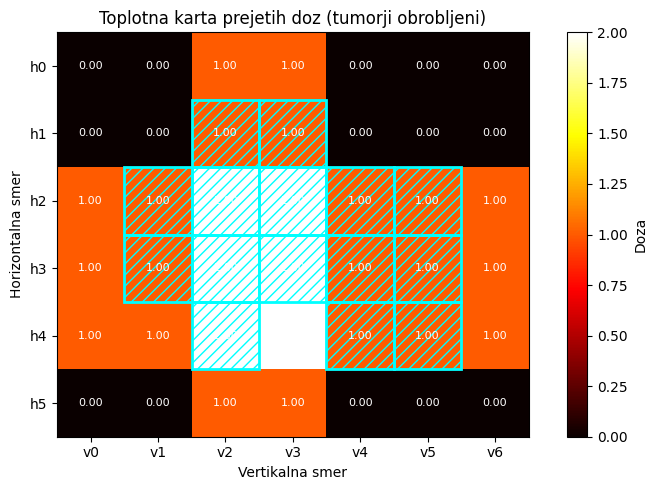

In [25]:
cells = [
    [False, False, False, False, False, False, False],
    [False, False, True,  True,  False, False, False],
    [False, True,  True,  True,  True,  True,  False],
    [False, True,  True,  True,  True,  True,  False],
    [False, False, True,  False, True,  True,  False],
    [False, False, False, False, False, False, False]
]

res = optimize_dose(cells, mode=1)

print("Status:", res.message)
print("Optimalna vrednost:", res.fun)

# Razbij spremenljivke na h in v
n_rows = len(cells)
n_cols = len(cells[0])

h = res.x[:n_rows]
v = res.x[n_rows:]

print("Horizontalni žarki (h):", h)
print("Vertikalni žarki (v):", v)

visualize_dose(cells, res)